# Boston house price prediction

In [1]:
import pandas as pd

path = "/content/boston_house_dataset.csv"
df = pd.read_csv(path)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


In [2]:
df.shape

(506, 14)

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.166008
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.372456
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.000000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,0.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


In [5]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


<Axes: >

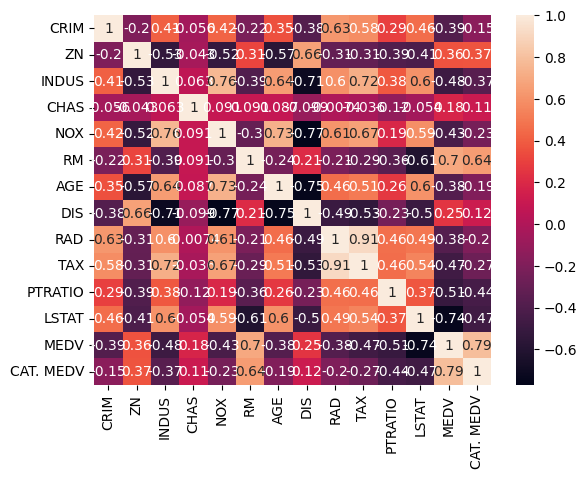

In [6]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)

In [7]:
X = df.drop(["MEDV", "CAT. MEDV"], axis=1)
y = df["MEDV"]

In [8]:
X[:2]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14


In [9]:
y[:2]

,MEDV
0,24.0
1,21.6


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,11.28


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # learn scaling
X_test = scaler.transform(X_test)         # apply same scaling

In [13]:
print(df.shape)
print(X.shape)
print(y.shape)

(506, 14)
(506, 12)
(506,)


In [15]:
X_train[:2]

array([[ 1.28770177, -0.50032012,  1.03323679, -0.27808871,  0.48925206,
        -1.42806858,  1.02801516, -0.80217296,  1.70689143,  1.57843444,
         0.84534281,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, -0.27808871, -0.15723342,
        -0.68008655, -0.43119908,  0.32434893, -0.62435988, -0.58464788,
         1.20474139, -0.5614742 ]])

In [16]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [35]:
X_train

tensor([[ 1.2877, -0.5003,  1.0332,  ...,  1.5784,  0.8453,  1.7535],
        [-0.3364, -0.5003, -0.4132,  ..., -0.5846,  1.2047, -0.5615],
        [-0.4033,  1.0133, -0.7152,  ..., -0.6027, -0.6372, -0.6516],
        ...,
        [-0.4055,  2.9593, -1.3034,  ..., -0.7473, -0.5923, -0.9107],
        [ 0.8519, -0.5003,  1.0332,  ...,  1.5784,  0.8453,  1.5226],
        [-0.3814, -0.5003, -0.3522,  ..., -0.1207,  1.1598, -0.2573]])

STEP 8: Neural Network **banana**

In [36]:
import torch
import torch.nn as nn

class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(12,32)
    self.fc2 = nn.Linear(32,16)
    self.fc3 = nn.Linear(16,1)
    self.relu = nn.ReLU()

  def forward(self,x):
    x =  self.relu(self.fc1(x))
    x =  self.relu(self.fc2(x))
    x =  self.fc3(x)
    return x

model = ANN()

In [37]:
# loss fucntion

In [38]:
loss_fn = nn.MSELoss()

In [39]:
# ⚙️ STEP 10: Optimizer

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [42]:
for epoch in range(1000):

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 612.4880981445312
Epoch 20, Loss: 603.2583618164062
Epoch 40, Loss: 595.8484497070312
Epoch 60, Loss: 583.6061401367188
Epoch 80, Loss: 559.7772827148438
Epoch 100, Loss: 514.4727172851562
Epoch 120, Loss: 437.8418273925781
Epoch 140, Loss: 333.45135498046875
Epoch 160, Loss: 224.44212341308594
Epoch 180, Loss: 143.046630859375
Epoch 200, Loss: 97.60840606689453
Epoch 220, Loss: 72.54658508300781
Epoch 240, Loss: 57.29436111450195
Epoch 260, Loss: 47.734561920166016
Epoch 280, Loss: 41.47161865234375
Epoch 300, Loss: 37.22099304199219
Epoch 320, Loss: 34.25218200683594
Epoch 340, Loss: 32.07853317260742
Epoch 360, Loss: 30.391393661499023
Epoch 380, Loss: 28.993202209472656
Epoch 400, Loss: 27.783111572265625
Epoch 420, Loss: 26.70292854309082
Epoch 440, Loss: 25.725982666015625
Epoch 460, Loss: 24.828187942504883
Epoch 480, Loss: 23.993995666503906
Epoch 500, Loss: 23.207332611083984
Epoch 520, Loss: 22.46494483947754
Epoch 540, Loss: 21.77175521850586
Epoch 560, Loss: 

In [43]:
X_test[1]

tensor([-0.4008,  1.2295, -0.6644,  3.5960, -0.9313,  0.6239, -1.2753,  0.1266,
        -0.6244, -0.9040, -0.3227, -1.2571])

In [44]:
model.eval()

with torch.no_grad():
    y_pred_test = model(X_test)
    test_loss = loss_fn(y_pred_test, y_test)

print("Test Loss:", test_loss.item())

Test Loss: 14.758252143859863


In [45]:
print("Actual:", y_test[:5])
print("Predicted:", y_pred_test[:5])

Actual: tensor([[23.6000],
        [32.4000],
        [13.6000],
        [22.8000],
        [16.1000]])
Predicted: tensor([[27.1901],
        [31.0465],
        [17.9586],
        [26.7693],
        [16.7369]])


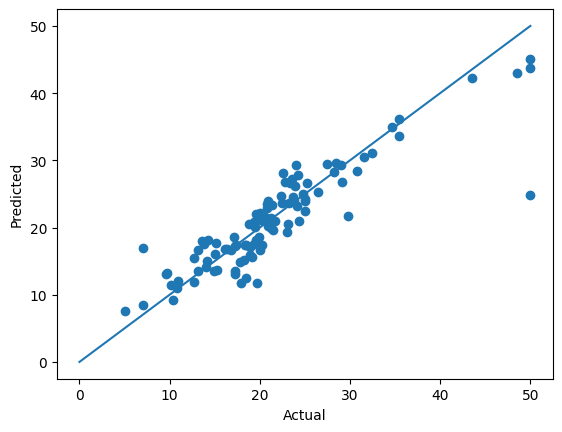

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test.numpy(), y_pred_test.numpy())
plt.plot([0,50],[0,50])  # perfect line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [47]:
torch.save({
    "model_state": model.state_dict(),
    "architecture": "12-32-16-1"
}, "model.pth")

In [48]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [49]:
scaler

StandardScaler()

In [55]:
print(X.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT'],
      dtype='object')


In [62]:
print(model.fc1.weight.shape)

torch.Size([32, 12])


In [63]:
import torch

weights = model.fc1.weight.detach().numpy()

importance = abs(weights).mean(axis=0)

print(importance)

[0.34633538 0.2433852  0.26124704 0.29981247 0.24096438 0.34797198
 0.2598057  0.2675585  0.28465876 0.30989707 0.335818   0.2901289 ]


In [67]:
features = X.columns

In [68]:
features

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT'],
      dtype='object')

In [70]:
for name, imp in zip(features, importance):
    print(name, imp)

CRIM 0.34633538
ZN 0.2433852
INDUS 0.26124704
CHAS 0.29981247
NOX 0.24096438
RM 0.34797198
AGE 0.2598057
DIS 0.2675585
RAD 0.28465876
TAX 0.30989707
PTRATIO 0.335818
LSTAT 0.2901289


In [72]:
import joblib

joblib.dump(features, "features.pkl")

['features.pkl']